In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.dataset.kitti_dataset import KittiDataset
from src.preprocessing.bev import bev_projection

from src.geometry.boxes import (
    create_box_corners_camera,
    box_parameters_from_lidar_corners,
    get_lidar_boxes
)

from src.geometry.transforms import (
    rectified_camera_to_lidar
)

from src.targets.bev_targets import (
    create_bev_targets
)

In [2]:
dataset = KittiDataset("../data/KITTI")

for idx in range(len(dataset)):

    candidate = dataset[idx]

    if any(
        obj["type"] == "Car"
        for obj in candidate["labels"]
    ):
        sample = candidate
        break

In [3]:
points = sample["points"]
labels = sample["labels"]
calib = sample["calib"]

bev = bev_projection(points)

In [4]:
boxes = get_lidar_boxes(
    labels,
    calib
)

print("Cars:", len(boxes))

for box in boxes:
    print(box)

Cars: 1
{'center_x': np.float64(58.78080130021213), 'center_y': np.float64(16.55963352878869), 'length': np.float64(3.689798112534668), 'width': np.float64(1.869895848993033), 'yaw': np.float64(0.0009206985495272654)}


In [5]:
targets = create_bev_targets(boxes)

In [6]:
print(
    "Heatmap:",
    targets["heatmap"].shape
)

print(
    "Offset:",
    targets["offset"].shape
)

print(
    "Size:",
    targets["size"].shape
)

print(
    "Rotation:",
    targets["rotation"].shape
)

Heatmap: (350, 400)
Offset: (2, 350, 400)
Size: (2, 350, 400)
Rotation: (2, 350, 400)


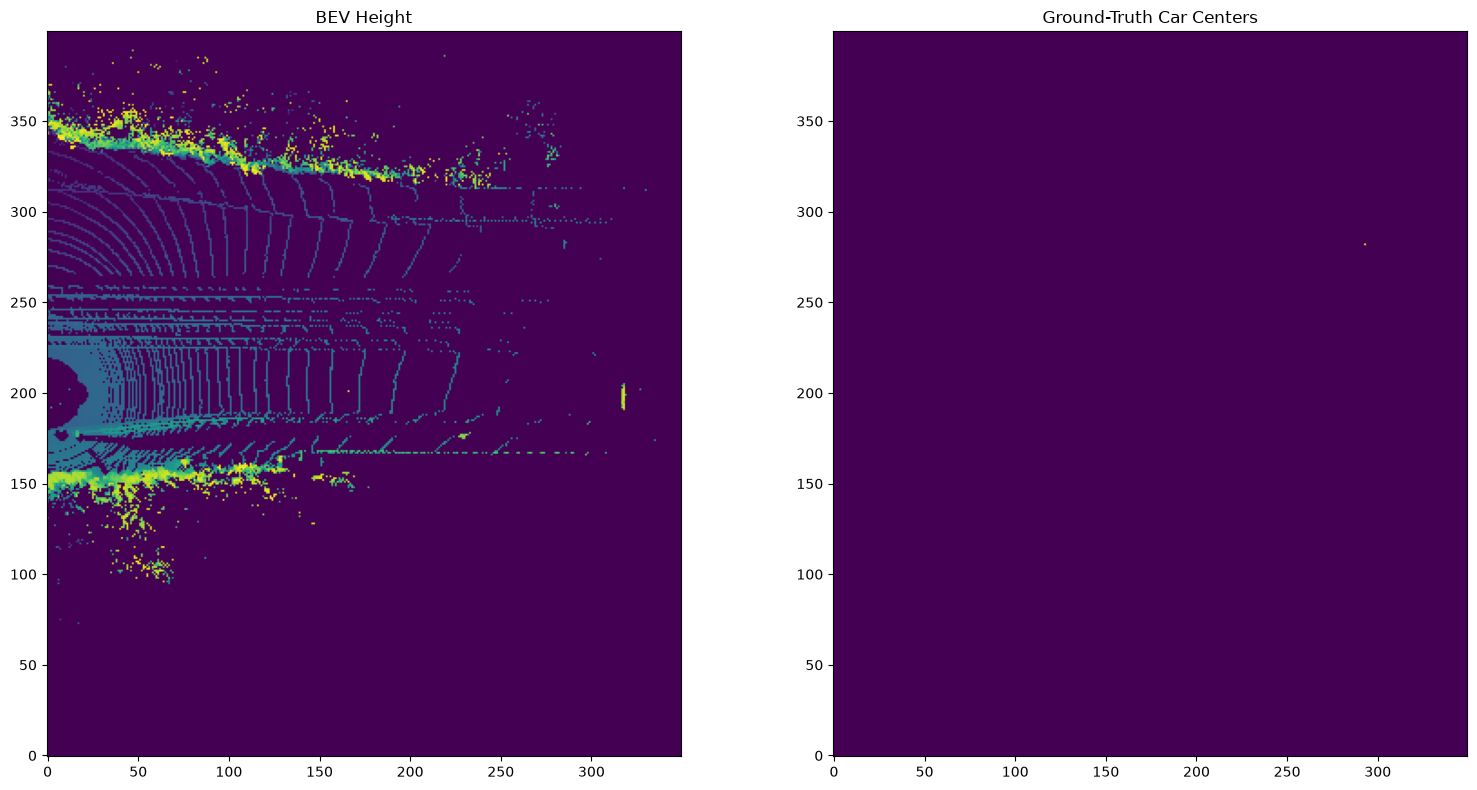

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

axes[0].imshow(
    bev[0].T,
    origin="lower"
)

axes[0].set_title(
    "BEV Height"
)

axes[1].imshow(
    targets["heatmap"].T,
    origin="lower"
)

axes[1].set_title(
    "Ground-Truth Car Centers"
)

plt.tight_layout()
plt.show()

In [8]:
center_indices = np.argwhere(
    targets["heatmap"] > 0
)

center_indices

array([[293, 282]])

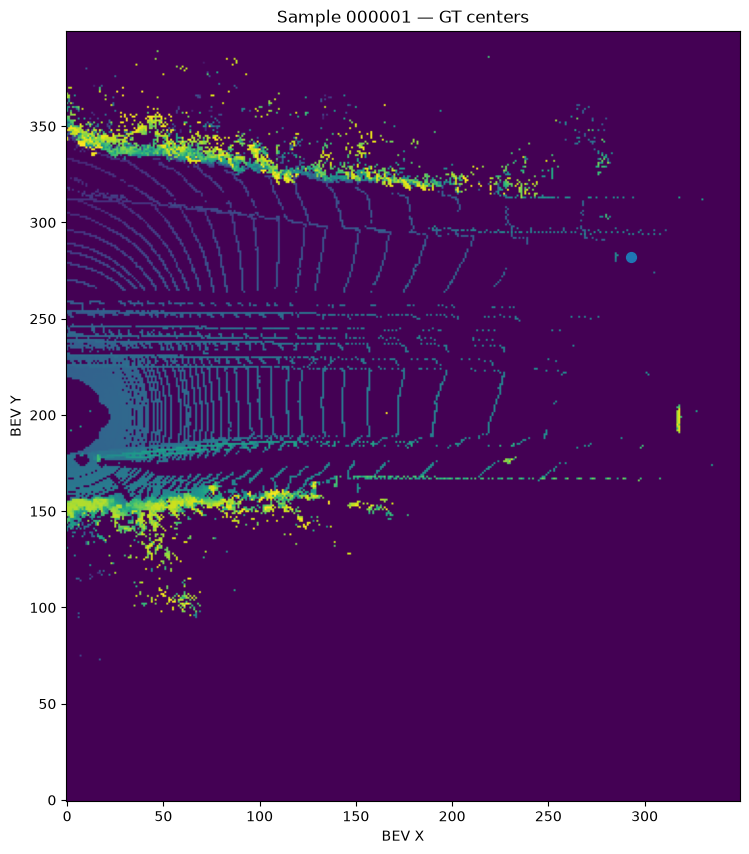

In [9]:
plt.figure(figsize=(10, 10))

plt.imshow(
    bev[0].T,
    origin="lower"
)

for x_idx, y_idx in center_indices:

    plt.scatter(
        x_idx,
        y_idx,
        s=50
    )

plt.title(
    f"Sample {sample['id']} — GT centers"
)

plt.xlabel("BEV X")
plt.ylabel("BEV Y")

plt.show()

In [10]:
x_idx, y_idx = center_indices[0]

print(
    "Cell:",
    x_idx,
    y_idx
)

print(
    "Heatmap:",
    targets["heatmap"][x_idx, y_idx]
)

print(
    "Offset:",
    targets["offset"][:, x_idx, y_idx]
)

print(
    "Length/width:",
    targets["size"][:, x_idx, y_idx]
)

print(
    "sin/cos yaw:",
    targets["rotation"][:, x_idx, y_idx]
)

Cell: 293 282
Heatmap: 1.0
Offset: [0.9040065  0.79816765]
Length/width: [3.689798  1.8698958]
sin/cos yaw: [9.206984e-04 9.999996e-01]
